In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Transform: converting images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                               # Converts PIL image to tensor
    transforms.Normalize((0.1307,),(0.3081,))            # Normalize with MNIST mean and std where the values are previously are calculated.
])

# MNIST dataset 
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

(X_train, y_train) = train_dataset.data, train_dataset.targets
(X_test, y_test) = test_dataset.data, test_dataset.targets

X_train = X_train / 255.0
X_test = X_test / 255.0

encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Y Training data shape:", y_train.shape)
print("Y Testing data shape:", y_test.shape)

np.random.seed(42)
torch.manual_seed(42)

# Convert to torch tensors
X_train = X_train.float()
y_train = y_train.long()
X_test = X_test.float()
y_test = y_test.long()

Training data shape: torch.Size([60000, 28, 28])
Testing data shape: torch.Size([10000, 28, 28])
Y Training data shape: torch.Size([60000])
Y Testing data shape: torch.Size([10000])


In [3]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader


def base_fn(model_class, lr=0.01, weight_decay=0.0):
    batch_size, lr = 64, lr
    num_epochs = 5
    model = model_class
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        # -------------------------
        # Training
        # -------------------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X.view(batch_X.size(0), -1))
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, -1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        # -------------------------
        # Validation
        # -------------------------
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X.view(batch_X.size(0), -1))
                loss = criterion(outputs, batch_y)

                val_running_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, -1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total

        # Store history
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2%} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2%}"
        )

    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time:.2f} seconds")

    # -------------------------
    # Visualization for this run
    # -------------------------
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker='o', label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], marker='o', label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model, history, total_time


#### Overfitting and Underfitting
- **Underfitting**
    - The model is too simple to learn the underlying structure of the data. High error on both training and test sets. (Like trying to fit a straight line to a complex curve).
    - **Training and Testing loss are high**

- **Overfitting**
    - The model learns the noise and specific details of the training data too well. It performs great on training data but fails on new, unseen data. (Like memorizing the answers to a practice test instead of learning the math).
    - **If training loss keeps going down but validation loss turns up after some epoch**

#### Base Model

This is the base model without **Weight Decay, Batch Normalization or Dropout**
- Batch_size = 64, lr = 0.01 
- This take around ~ 8.9 seconds and ~ 97.51 accuracy

Epoch 1/5 | Train Loss: 0.2457 | Train Acc: 92.63% | Val Loss: 0.1755 | Val Acc: 95.15%
Epoch 2/5 | Train Loss: 0.1490 | Train Acc: 95.73% | Val Loss: 0.1263 | Val Acc: 96.66%
Epoch 3/5 | Train Loss: 0.1246 | Train Acc: 96.56% | Val Loss: 0.1360 | Val Acc: 96.59%
Epoch 4/5 | Train Loss: 0.1075 | Train Acc: 96.95% | Val Loss: 0.1502 | Val Acc: 96.56%
Epoch 5/5 | Train Loss: 0.1073 | Train Acc: 97.15% | Val Loss: 0.1740 | Val Acc: 96.29%

Total training time: 10.94 seconds


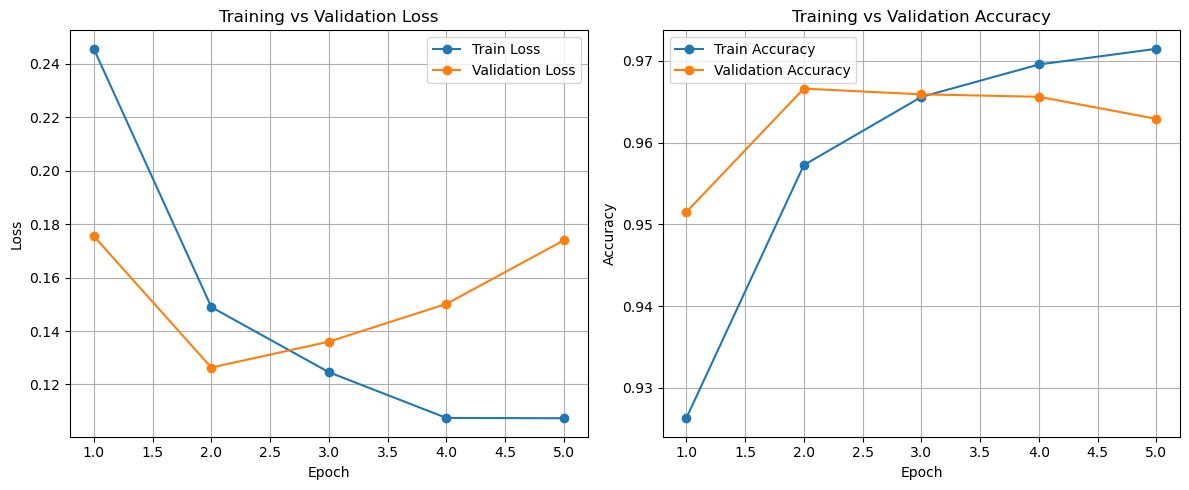

In [16]:
class MLP_base(nn.Module):
    def __init__(self, il = 784, hl = [128, 128], ol = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(il, hl[0]),
            nn.ReLU(),
            nn.Linear(hl[0], hl[1]),
            nn.ReLU(),
            nn.Linear(hl[1], ol)
        )
    def forward(self, x):
        return self.net(x)
    
trained_base, hist_base, time_base = base_fn(model_class=MLP_base(), lr=0.01)

#### Dropout 
- The basic idea is during training, we randomly **turn off** a percentage of neurons in a layer for each pass
- This is done so that neurons do not rely on other neurons to do the heavy-lifting. This helps each neuron to behave independently.
- **This is majorly done to prevent overfitting**

- hl = [128], Batch_size = 64, lr = 0.01 

Epoch 1/5 | Train Loss: 0.6526 | Train Acc: 81.03% | Val Loss: 0.2890 | Val Acc: 92.56%
Epoch 2/5 | Train Loss: 0.5290 | Train Acc: 85.99% | Val Loss: 0.2625 | Val Acc: 93.14%
Epoch 3/5 | Train Loss: 0.5171 | Train Acc: 86.78% | Val Loss: 0.2515 | Val Acc: 93.44%
Epoch 4/5 | Train Loss: 0.4999 | Train Acc: 87.52% | Val Loss: 0.2670 | Val Acc: 93.13%
Epoch 5/5 | Train Loss: 0.4901 | Train Acc: 87.74% | Val Loss: 0.2531 | Val Acc: 93.46%

Total training time: 12.99 seconds


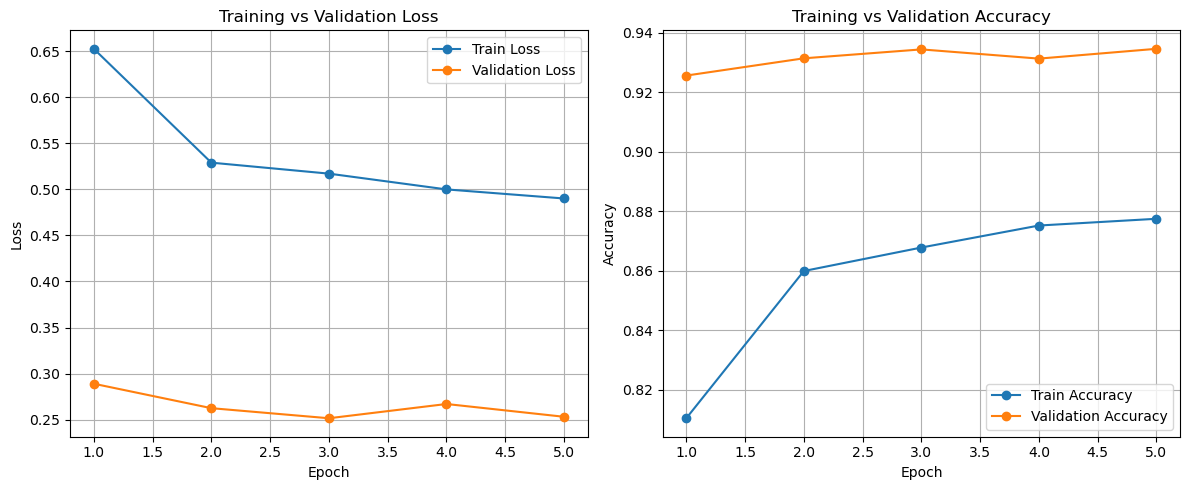

In [17]:
class MLP_dropout(nn.Module):
    def __init__(self, il = 784, hl = [128, 128], ol = 10, p = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(il, hl[0]),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hl[0], hl[1]),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hl[1], ol)
        )
    def forward(self, x):
        return self.net(x)
    
trained_drop, hist_drop, time_drop = base_fn(model_class=MLP_dropout(), lr=0.01)

#### Batch Normalization
- The basic idea is that, it scales the output of the layers so that they have mean 0 and variance 1 for every mini-Batch
- It stabilizes the learning process. It allows for higher learning rates and acts as a minor regularizer, often making Dropout less necessary.

Epoch 1/5 | Train Loss: 0.2064 | Train Acc: 93.52% | Val Loss: 0.1053 | Val Acc: 96.71%
Epoch 2/5 | Train Loss: 0.1065 | Train Acc: 96.70% | Val Loss: 0.1005 | Val Acc: 96.86%
Epoch 3/5 | Train Loss: 0.0831 | Train Acc: 97.32% | Val Loss: 0.0795 | Val Acc: 97.51%
Epoch 4/5 | Train Loss: 0.0675 | Train Acc: 97.78% | Val Loss: 0.0743 | Val Acc: 97.64%
Epoch 5/5 | Train Loss: 0.0587 | Train Acc: 98.11% | Val Loss: 0.0704 | Val Acc: 97.70%

Total training time: 11.71 seconds


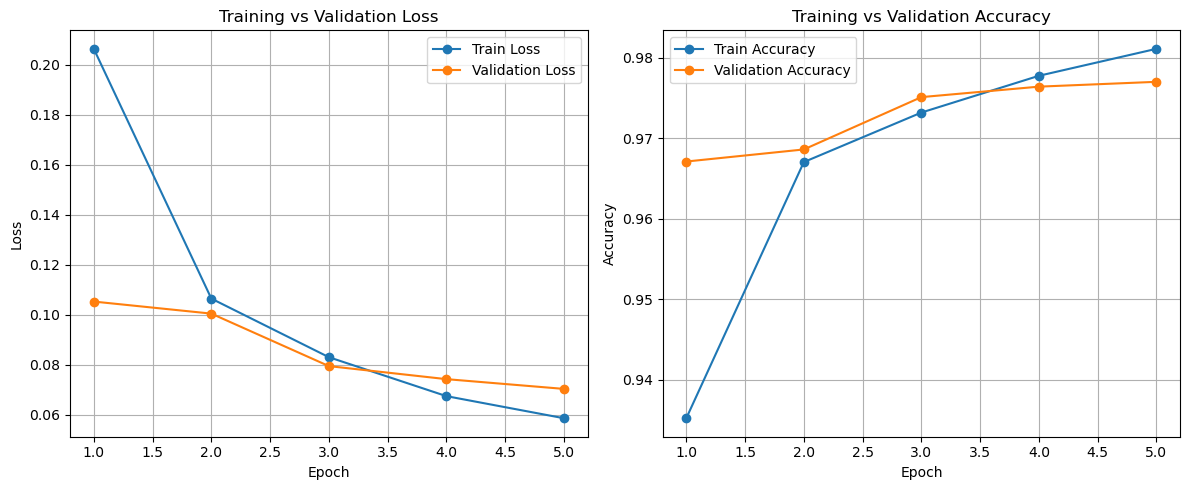

In [18]:
class MLP_batch(nn.Module):
    def __init__(self, il = 784, hl = [128, 128], ol = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(il, hl[0]),
            nn.BatchNorm1d(hl[0]),
            nn.ReLU(),
            nn.Linear(hl[0], hl[1]),
            nn.BatchNorm1d(hl[1]),
            nn.ReLU(),
            nn.Linear(hl[1], ol)
        )
    def forward(self,x):
        return self.net(x)

trained_batch, hist_batch, time_batch = base_fn(model_class=MLP_batch(), lr=0.01)

#### Weight Decay
- It adds a penalty to the Loss Function based on the size of the weights
- It forces the model to keep weights small. Smaller weights mean the model is "simpler" and less likely to react wildly to small fluctuations in input data.
- function line AdamW() will have Weight Decay built-in them

Epoch 1/5 | Train Loss: 0.2517 | Train Acc: 92.41% | Val Loss: 0.1658 | Val Acc: 94.90%
Epoch 2/5 | Train Loss: 0.1682 | Train Acc: 95.08% | Val Loss: 0.1911 | Val Acc: 94.54%
Epoch 3/5 | Train Loss: 0.1562 | Train Acc: 95.48% | Val Loss: 0.1952 | Val Acc: 94.28%
Epoch 4/5 | Train Loss: 0.1451 | Train Acc: 95.87% | Val Loss: 0.1720 | Val Acc: 95.50%
Epoch 5/5 | Train Loss: 0.1395 | Train Acc: 95.99% | Val Loss: 0.1396 | Val Acc: 95.87%

Total training time: 38.88 seconds


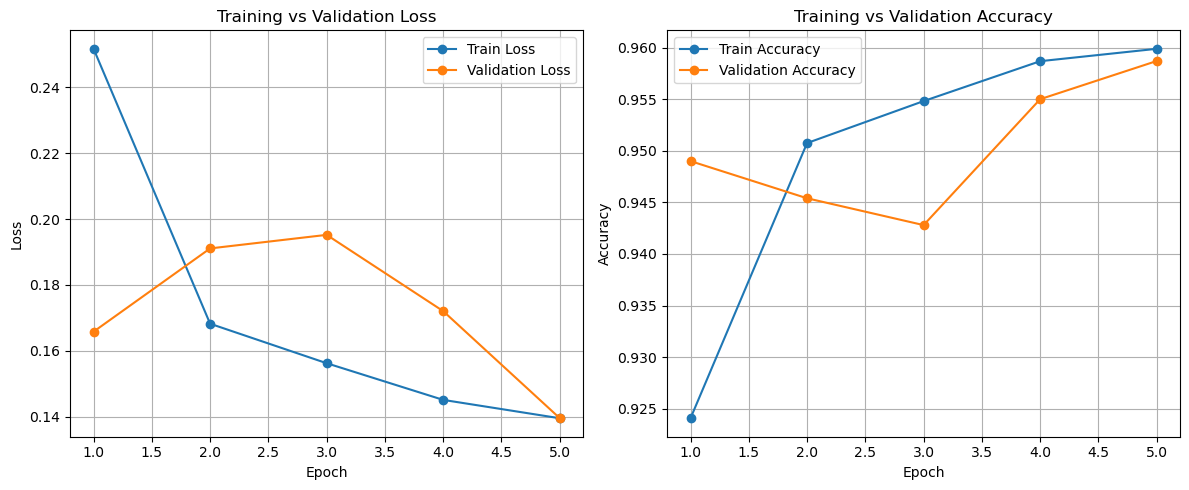

In [19]:
class MLP_decay(nn.Module):
    def __init__(self, il = 784, hl = [128, 128], ol = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(il, hl[0]),
            nn.ReLU(),
            nn.Linear(hl[0], hl[1]),
            nn.ReLU(),
            nn.Linear(hl[1], ol)
        )
    def forward(self, x):
        return self.net(x)

trained_decay, hist_decay, time_decay = base_fn(model_class=MLP_decay(), lr=0.01, weight_decay=1e-4)

#### Combining all

Epoch 1/5 | Train Loss: 0.4508 | Train Acc: 86.24% | Val Loss: 0.1706 | Val Acc: 94.55%
Epoch 2/5 | Train Loss: 0.3384 | Train Acc: 89.72% | Val Loss: 0.1458 | Val Acc: 95.69%
Epoch 3/5 | Train Loss: 0.3256 | Train Acc: 90.38% | Val Loss: 0.1414 | Val Acc: 95.80%
Epoch 4/5 | Train Loss: 0.3281 | Train Acc: 90.29% | Val Loss: 0.1471 | Val Acc: 95.65%
Epoch 5/5 | Train Loss: 0.3188 | Train Acc: 90.44% | Val Loss: 0.1348 | Val Acc: 95.72%

Total training time: 18.23 seconds


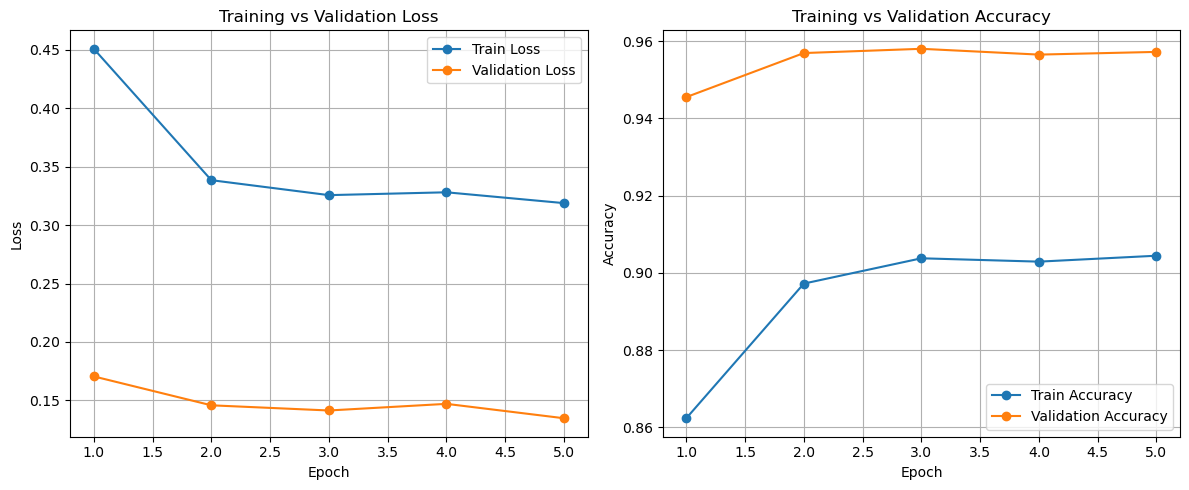

In [4]:
class MLP(nn.Module):
    def __init__(self, il = 784, hl = [128, 128], ol = 10, p = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(il, hl[0]),
            nn.BatchNorm1d(hl[0]),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hl[0], hl[1]),
            nn.BatchNorm1d(hl[1]),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hl[1], ol)
        )
    def forward(self, x):
        return self.net(x)
    
trained_all, hist_all, time_all = base_fn(model_class=MLP(), lr=0.01, weight_decay=1e-4)

#### NOTE

- **You don't have to use all the regularization technique at once.** In fact, if you're just starting out or working with a small dataset, using all three can sometimes be overkill and actually make it harder for your model to learn

| Technique | When to use it | Why? |
| :--- | :--- | :--- |
| **Weight Decay ($L_2$)** | **Almost always.** | It is very "cheap" computationally and acts as a gentle baseline to keep weights from exploding. Most modern optimizers (like AdamW) have this on by default. |
| **Batch Normalization** | **Deep Networks.** | If your model has more than 2 or 3 hidden layers, Batch Norm is essential. It stabilizes training and allows you to use higher learning rates. |
| **Dropout** | **Large Networks / Overfitting.** | If you see a large gap between your training accuracy (99%) and validation accuracy (85%), Dropout is your best tool to bridge that gap. |



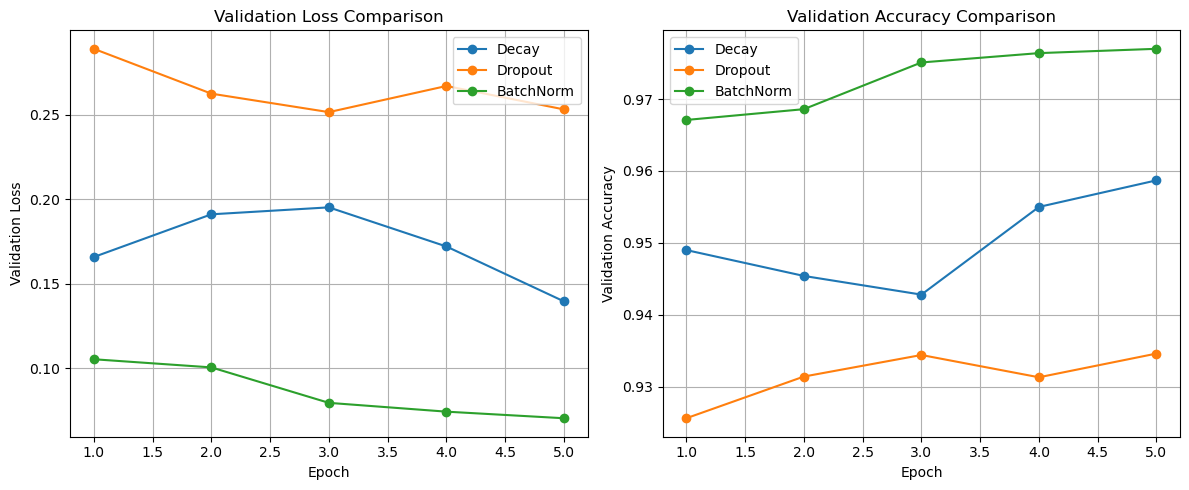

In [20]:


def compare_histories(histories, labels):
    epochs = range(1, len(histories[0]["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Validation Loss comparison
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        plt.plot(epochs, hist["val_loss"], marker='o', label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)

    # Validation Accuracy comparison
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        plt.plot(epochs, hist["val_acc"], marker='o', label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

compare_histories(
    [hist_decay, hist_drop, hist_batch],
    ["Decay", "Dropout", "BatchNorm"]
)